In [1]:
#data preprocessing project
#Generate synthetic dataset
#perform EDA
#Clean data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
#reproducibility
np.random.seed(42)

In [3]:
#Generate synthetic data
n=100

df=pd.DataFrame({
    "EmployeeID":np.arange(1001,1001+n),
    "Age":np.random.randint(20,60,n),
    "Gender":np.random.choice(["Male","Female"],n),

    "Department":np.random.choice(
        ["IT","HR","Finance","Sales","Marketing"],
        n
    ),
    "Experience":np.random.randint(1,20,n),
    "Salary":np.random.randint(25000,120000,n),
    "PerformanceScore":np.random.randint(1,6,n)
})


In [4]:
#Add missing values
df.loc[[4,12,25],"Age"] = np.nan
df.loc[[8,18],"Salary"]= np.nan
df.loc[[15,35],"Department"] = np.nan



In [5]:
#Add incorrect text values
df.loc[5,"Gender"] = "M"
df.loc[16,"Gender"] = "F"
df.loc[28,"Department"] = "IT Dept"
df.loc[45,"Department"] = "finance"

In [6]:
#Add outliers
df.loc[2,"Salary"] = 500000
df.loc[20,"Salary"] = 700000
df.loc[60,"Salary"] = 900000


In [7]:
#Add abnormal data
df.loc[30,"Age"] = -5
df.loc[55,"Age"] = 150
df.loc[40,"Experience"] = -2
df.loc[70,"PerformanceScore"] = 10


In [8]:
#Add duplicate rows
duplicates = df.iloc[[10,20,30]]
df = pd.concat([df,duplicates],ignore_index = True)
print("Shape:",df.shape)
print(df.head())

Shape: (103, 7)
   EmployeeID   Age  Gender Department  Experience    Salary  PerformanceScore
0        1001  58.0  Female      Sales           4   98847.0                 2
1        1002  48.0    Male    Finance           1  107750.0                 2
2        1003  34.0    Male         IT          14  500000.0                 2
3        1004  27.0  Female      Sales          16   53251.0                 2
4        1005   NaN  Female         IT           8   50945.0                 3


In [9]:
#Exploratory data analysis
print("\nDataset Information\n")
print(df.info())

print("\nSummary Statistics\n")
print(df.describe(include="all"))

print("\nDuplicate Rows:",df.duplicated().sum())


Dataset Information

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        103 non-null    int64  
 1   Age               100 non-null    float64
 2   Gender            103 non-null    str    
 3   Department        101 non-null    str    
 4   Experience        103 non-null    int32  
 5   Salary            101 non-null    float64
 6   PerformanceScore  103 non-null    int32  
dtypes: float64(2), int32(2), int64(1), str(2)
memory usage: 5.0 KB
None

Summary Statistics

         EmployeeID         Age Gender Department  Experience         Salary  \
count    103.000000  100.000000    103        101  103.000000     101.000000   
unique          NaN         NaN      4          7         NaN            NaN   
top             NaN         NaN   Male         IT         NaN            NaN   
freq            NaN         NaN     58         2

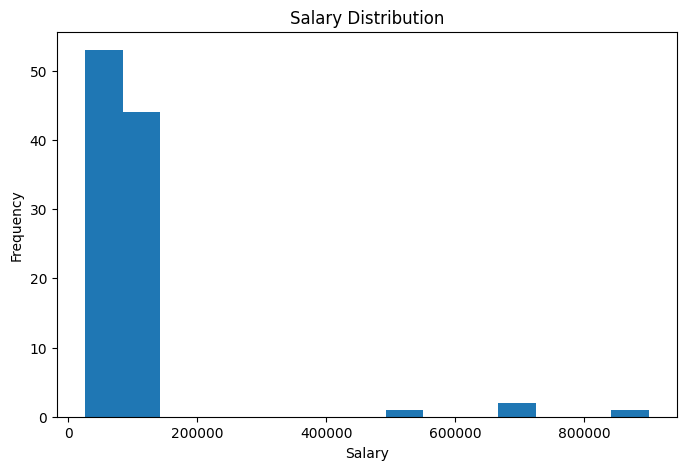

In [10]:
#Visualization

#Histogram -  Salary Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Salary"].dropna(),bins=15)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

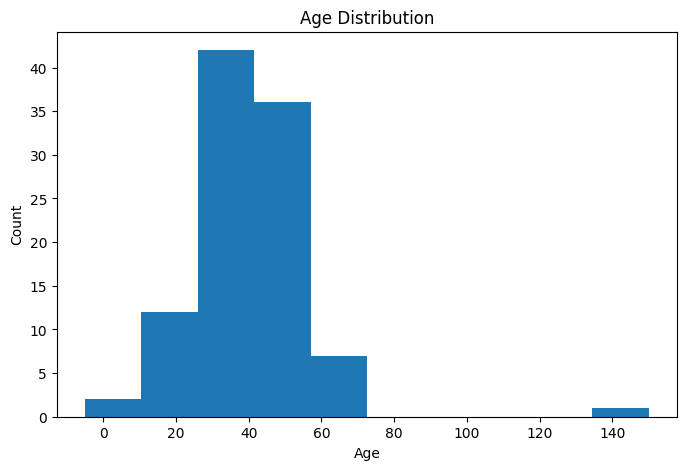

In [12]:
#Histogram - Age Distribution

plt.figure(figsize=(8,5))
plt.hist(df["Age"].dropna(),bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

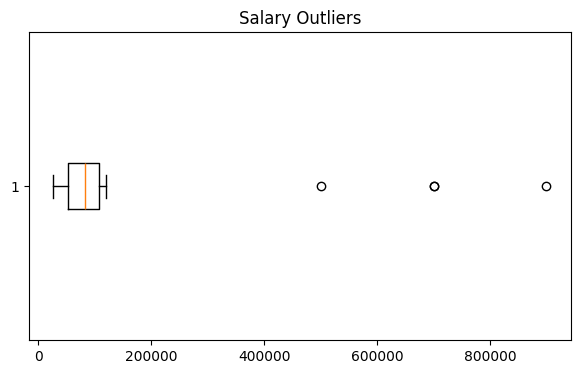

In [13]:
#Boxplot - Salary
plt.figure(figsize=(7,4))
plt.boxplot(df["Salary"].dropna(),vert=False)
plt.title("Salary Outliers")
plt.show()

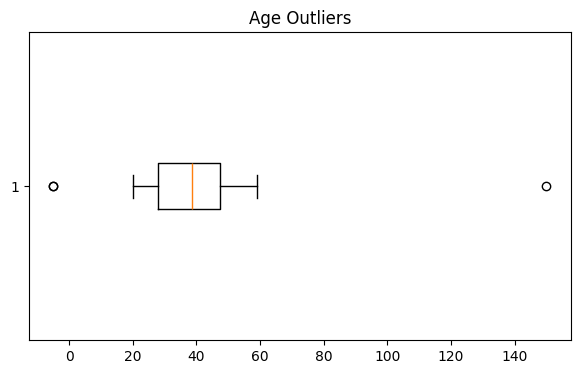

In [14]:
#Boxplot - Age
plt.figure(figsize=(7,4))
plt.boxplot(df["Age"].dropna(),vert=False)
plt.title("Age Outliers")
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'xtricks'

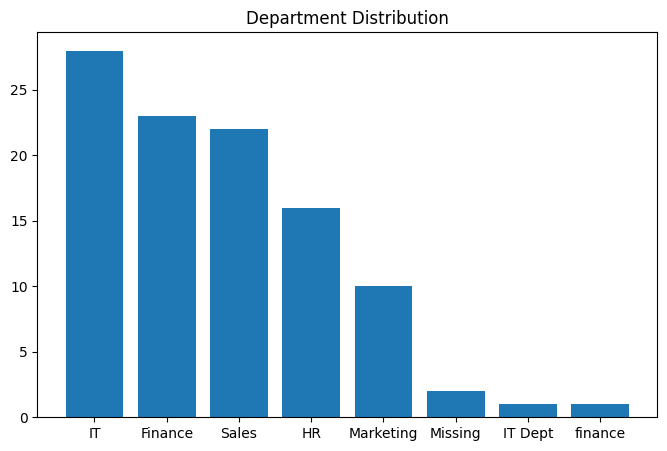

In [16]:
#Barchart

dept_counts = df["Department"].fillna("Missing").value_counts(dropna=False)

plt.figure(figsize=(8,5))
plt.bar(dept_counts.index.astype(str),dept_counts.values)
plt.title("Department Distribution")
plt.xtricks(rotation=30)
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'xtricks'

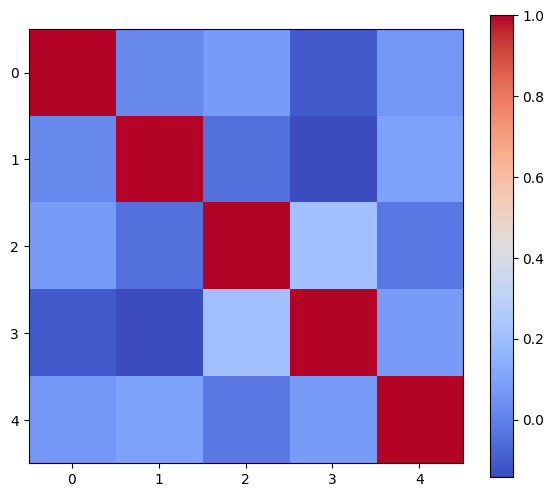

In [19]:
#Correlation heatmap
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()
plt.figure(figsize=(7,6))
plt.imshow(corr,cmap="coolwarm",interpolation="nearest")
plt.colorbar()

plt.xtricks(range(len(corr.columns)),corr.columns,rotation=90)
plt.ytricks(range(len(corr.columns)),corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [20]:
#data cleaning

print("\nCleaning Started...")

#Remove the duplicates
df = df.drop_duplicates()

#Fix Gender
df["Gender"] = df["Gender"].replace({
    "M":"Male",
    "F":"Female"
})

#Fix department
df["Department"] = df["Department"].replace({
    "IT Dept":"IT",
    "finance":"Finance"
})

#Replace Abnormal Age
df.loc[(df["Age"]<18) | (df["Age"]>70),"Age"] = np.nan


Cleaning Started...


In [21]:
#Replace abnormal performance

df.loc[df["PerformanceScore"]>5,"PerformanceScore"] = np.nan

#Fill Missing numerical
df["Age"].fillna(df["Age"].median(),inplace=True)
df["Salary"].fillna(df["Salary"].median(),inplace=True)
df["Experience"].fillna(df["Experience"].median(),inplace=True)

df["PerformanceScore"].fillna(
    df["PerformanceScore"].median(),
    inplace = True
)

C:\Users\sivas\AppData\Local\Temp\ipykernel_35620\2111373499.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"].fillna(df["Age"].median(),inplace=True)
C:\Users\sivas\AppData\Local\Temp\ipykernel_35620\2111373499.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignmen

0     2.0
1     2.0
2     2.0
3     2.0
4     3.0
     ... 
95    1.0
96    4.0
97    1.0
98    1.0
99    5.0
Name: PerformanceScore, Length: 100, dtype: float64

In [27]:
#Fill Missing Categorical
df["Department"]= df["Department"].fillna(df["Department"].mode()[0])

#Outlier Treatment
#IQR METHOD - Interquartile range = Q3-Q1

Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR=Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

df["Salary"] = np.where(
    df["Salary"]>upper,
    upper,
    df["Salary"]
)

df["Salary"] = np.where(
    df["Salary"]<lower,
    lower,
    df["Salary"]
)

In [28]:
#Encoding
df = pd.get_dummies(
    df,
    columns=["Gender","Department"],
    drop_first=True
)

In [30]:
#Final Dataset

print("\nFinal Shape :",df.shape)
print("\nMissing values\n")
print(df.isnull().sum())
print("\nDuplicates:",df.duplicated().sum())
print("\nFirst Five Rows\n")
print(df.head())


Final Shape : (100, 10)

Missing values

EmployeeID              0
Age                     5
Experience              0
Salary                  2
PerformanceScore        1
Gender_Male             0
Department_HR           0
Department_IT           0
Department_Marketing    0
Department_Sales        0
dtype: int64

Duplicates: 0

First Five Rows

   EmployeeID   Age  Experience      Salary  PerformanceScore  Gender_Male  \
0        1001  58.0           4   98847.000               2.0        False   
1        1002  48.0           1  107750.000               2.0         True   
2        1003  34.0          14  183296.375               2.0         True   
3        1004  27.0          16   53251.000               2.0        False   
4        1005   NaN           8   50945.000               3.0        False   

   Department_HR  Department_IT  Department_Marketing  Department_Sales  
0          False          False                 False              True  
1          False          False    

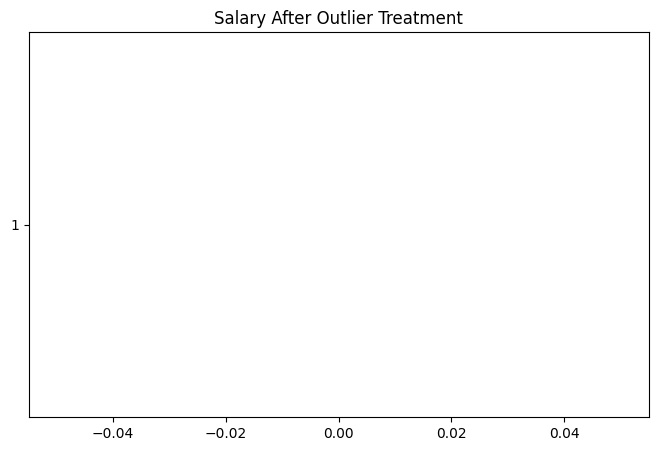

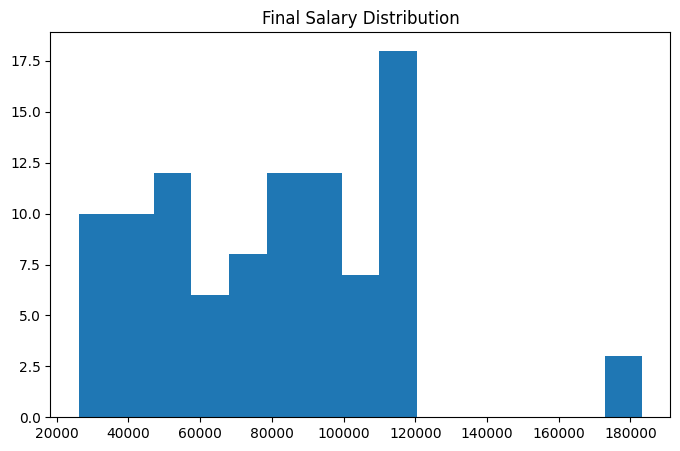

In [31]:
#Final Visualization

plt.figure(figsize=(8,5))
plt.boxplot(df["Salary"],vert=False)
plt.title("Salary After Outlier Treatment")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["Salary"],bins=15)
plt.title("Final Salary Distribution")
plt.show()